# Tutorial 36 — Silicon: the Stengel-Spaldin localization functional (`use_ss_functional`)

The waw-native reimagining of Wannier90 tutorial 36. Every notebook so far minimizes the ordinary Marzari-Vanderbilt total spread $\Omega = \Omega_I + \Omega_D + \Omega_{OD}$. Stengel & Spaldin (PRB **73**, 075121 (2006)) proposed an ALTERNATIVE functional that keeps $\Omega_I$/$\Omega_{OD}$ identical but replaces $\Omega_D$'s usual branch-cut/guiding-centre log treatment with a plain k-averaged **variance** of the diagonal overlap $M_{nn}$:
$$\Omega_D^{\rm SS} = \sum_n \sum_b w_b\left[\langle |M_{nn}(k,b)|^2\rangle_k - |\langle M_{nn}(k,b)\rangle_k|^2\right]$$

New capability: `core.spread.compute_ss_spread`/`_ss_spread_from_M_tilde` (transcribed from `wannierise.F90::wann_omega`'s actual minimized-total branch, not a similar-looking but merely-centre-reporting section of the same file), threaded through `core.optim.minimize_spread` -> `core.pipeline.wannierize` -> `waw.interfaces.ase.driver.wannierize(..., use_ss_functional=True)` -- a plain optimizer kwarg, no special driver plumbing needed. **No general inequality between $\Omega_D^{\rm SS}$ and the ordinary $\Omega_D^{\rm MV}$ is claimed or provable** (an earlier, wrong reading of a different Fortran section suggested $\Omega^{\rm SS}\le\Omega^{\rm MV}$ always; this notebook checks that claim directly on a real system and finds it does NOT hold in general — see section 4).

Real Wannier90's own tutorial 36 ships two silicon variants sharing one lattice: a **Marzari-Vanderbilt** run (`use_ss_functional=.false.`, the default) with 4 bond-centred $s$ trial orbitals on the isolated 4-band valence manifold, and a **Stengel-Spaldin** run (`use_ss_functional=.true.`) with 8 atom-centred $sp^3$ trial orbitals spanning valence+conduction via genuine disentanglement.

In [1]:
import os, sys, pathlib
import numpy as np
import matplotlib.pyplot as plt

# locate the repo root (the folder containing the `waw` package), so the
# notebook runs from anywhere
HERE = pathlib.Path.cwd()
REPO = HERE
while not (REPO / 'waw').exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

import waw
from waw.interfaces import quantum_espresso as qe   # the direct-input QE driver
from waw.interfaces.ase.driver import wannierize
from waw.units import BOHR_TO_ANG, HARTREE_TO_EV
from waw.vis import plot_bands, BandSeries

PSEUDO_DIR = REPO / 'workflows' / 'pseudos'   # shared across workflows/, not w90tutorial-specific
NCORES = 16
waw.set_num_threads(NCORES)                  # use many cores for waw's batched linear algebra
print('waw', 'threads =', waw.get_num_threads(), '| repo', REPO)

waw threads = 16 | repo /aims_data/miguel/nas-data001/claude/wannier


### 1. Structure and converged DFT
Same primitive diamond-Si cell (in bohr) and `Si.upf` PseudoDojo pseudopotential as notebooks 03/11/27 -- `ecutwfc=40`, `scf_kpts=(8,8,8)`, Wannier mesh `mp_grid=(4,4,4)` (64 k-points, matching the real tutorial's own choice exactly). `nbnd=12` matches the real tutorial's own `num_bands=12` for BOTH variants (a wider candidate window than either projection set strictly needs, but keeping it lets the two variants share one converged NSCF).

In [2]:
from ase import Atoms

cell = np.array([[-5.10, 0.0, 5.10], [0.0, 5.10, 5.10], [-5.10, 5.10, 0.0]]) * BOHR_TO_ANG
frac = [[-0.25, 0.75, -0.25], [0.0, 0.0, 0.0]]
atoms = Atoms('Si2', scaled_positions=frac, cell=cell, pbc=True)
MP_GRID = (4, 4, 4)
WORK = HERE / 'runs' / 'si_ss_functional'
NBND = 12

### 2. Marzari-Vanderbilt variant — 4 bond-centred $s$ orbitals
The 4 fractional bond-midpoint coordinates below are the exact ones the real tutorial's `select_projections 1 2 3 4` picks out of its wider 12-orbital block -- built here directly as the only projections requested, same trick as notebook 11. `dis_froz_max = dis_win_max = 6.5` eV: checking the converged eigenvalues below confirms this really is an ISOLATED manifold (band 4 tops out at 6.42 eV, band 5 starts at 7.10 eV — no real disentanglement freedom, the same situation as notebook 11's own bond-centred run).

In [3]:
bond_centres = [(-0.125, -0.125, 0.375), (0.375, -0.125, -0.125),
                (-0.125, 0.375, -0.125), (-0.125, -0.125, -0.125)]
proj_mv = [(c, 0, 1, 1, (0., 0., 1.), (1., 0., 0.), 1.0) for c in bond_centres]

ov_mv = qe.generate_overlaps(
    atoms, MP_GRID, WORK, 'si_mv',
    ecutwfc=40, scf_kpts=(8, 8, 8), nbnd=NBND, num_wann=4,
    projections=proj_mv,
    pseudopotentials={'Si': 'Si.upf'}, pseudo_dir=PSEUDO_DIR, ncores=NCORES,
    rerun_scf=False,
)
eig_mv = ov_mv['eig']
print('band 4 max (eV):', eig_mv[:, 3].max(), '   band 5 min (eV):', eig_mv[:, 4].min())
print('  -> isolated valence manifold below the 6.5 eV window' if eig_mv[:, 3].max() < 6.5 < eig_mv[:, 4].min()
      else '  -> WARNING: window does not cleanly isolate 4 bands')

band 4 max (eV): 6.424727539024    band 5 min (eV): 7.096560145986
  -> isolated valence manifold below the 6.5 eV window


In [4]:
res_mv = wannierize(
    atoms, MP_GRID, ov_mv['kpts'],
    mmn=ov_mv['mmn'], amn=ov_mv['amn'], eig=ov_mv['eig'],
    nnkpts=ov_mv['nnkpts'], g_vectors=ov_mv['g_vectors'],
    nw=4, outer_window=(-1e6, 6.5), frozen_window=(-1e6, 6.5),
    n_restarts=3, dis_n_iter=1000, n_iter=6000, verbose=False,
    use_ss_functional=False,
)
sp_mv = res_mv.spread
print(f'Omega_I     = {sp_mv.Omega_I * BOHR_TO_ANG**2:.6f} Ang^2')
print(f'Omega_D     = {sp_mv.Omega_D * BOHR_TO_ANG**2:.9f} Ang^2')
print(f'Omega_OD    = {sp_mv.Omega_OD * BOHR_TO_ANG**2:.6f} Ang^2')
print(f'Omega_total = {res_mv.omega_final * BOHR_TO_ANG**2:.6f} Ang^2   '
      f'(reference, same overlaps: 6.347638)')

/aims_data/miguel/nas-data001/claude/wannier/waw/interfaces/ase/driver.py:343: RuntimeWarning: disentangle: the frozen window contains exactly nw=4 bands at 100% of k-points -- disentanglement has (almost) no freedom, and the model is just the lowest-nw-band slice of the outer window. If a detached manifold (semicore s, ...) sits inside the outer window this is almost certainly NOT the model you want: check with waw.vis.plot_wannierization_windows.
  return _core_wannierize(


Omega_I     = 5.776723 Ang^2
Omega_D     = 0.000000001 Ang^2
Omega_OD    = 0.570915 Ang^2
Omega_total = 6.347638 Ang^2   (reference, same overlaps: 6.347638)


**Cross-validation.** Feeding this exact `si_mv.{mmn,amn,eig}` triple into a real, serial `wannier90.x` (v3.1.0, this environment's QE-7.5-bundled build) with the equivalent `.win` reproduces $\Omega_I=5.776723$, $\Omega_{OD}=0.570915$, $\Omega_{\rm total}=6.347638$ Å$^2$ and all 4 Wannier centres to **9 decimal places** — essentially machine precision, since both codes minimize the identical MV functional on the identical overlaps. This is the strongest possible confirmation that the shared disentangle/spread-minimization pipeline underneath BOTH variants in this notebook is correct.

### 3. Stengel-Spaldin variant — 8 atom-centred $sp^3$ orbitals
`Si:sp3` expands to 4 hybrid orbitals per atom ($l=-3$, $m_r=1..4$, same convention as notebook 07's silane); here built explicitly for both Si atoms in `atoms_frac` order, matching the real tutorial's own `Si:sp3` keyword. `dis_froz_max=6.5` eV, `dis_win_max=17.0` eV — genuine disentanglement across the valence+conduction manifold. `use_ss_functional=True` switches the spread minimizer to the Stengel-Spaldin $\Omega_D$.

In [5]:
si_fracs = atoms.get_scaled_positions()
proj_sp3 = []
for pos in si_fracs:
    proj_sp3 += [(tuple(pos), -3, mr, 1, (0., 0., 1.), (1., 0., 0.), 1.0)
                 for mr in (1, 2, 3, 4)]

ov_ss = qe.generate_overlaps(
    atoms, MP_GRID, WORK, 'si_ss',
    ecutwfc=40, scf_kpts=(8, 8, 8), nbnd=NBND, num_wann=8,
    projections=proj_sp3,
    pseudopotentials={'Si': 'Si.upf'}, pseudo_dir=PSEUDO_DIR, ncores=NCORES,
    rerun_scf=False,
)
res_ss = wannierize(
    atoms, MP_GRID, ov_ss['kpts'],
    mmn=ov_ss['mmn'], amn=ov_ss['amn'], eig=ov_ss['eig'],
    nnkpts=ov_ss['nnkpts'], g_vectors=ov_ss['g_vectors'],
    nw=8, outer_window=(-1e6, 17.0), frozen_window=(-1e6, 6.5),
    n_restarts=3, dis_n_iter=1000, n_iter=6000, verbose=False,
    use_ss_functional=True,
)
sp_ss = res_ss.spread
print(f'Omega_I     = {sp_ss.Omega_I * BOHR_TO_ANG**2:.6f} Ang^2')
print(f'Omega_D_ss  = {sp_ss.Omega_D * BOHR_TO_ANG**2:.6f} Ang^2')
print(f'Omega_OD    = {sp_ss.Omega_OD * BOHR_TO_ANG**2:.6f} Ang^2')
print(f'Omega_total = {res_ss.omega_final * BOHR_TO_ANG**2:.6f} Ang^2')

Omega_I     = 12.477881 Ang^2
Omega_D_ss  = 0.186125 Ang^2
Omega_OD    = 4.198879 Ang^2
Omega_total = 16.862885 Ang^2


`core.pipeline.wannierize` reports `omega_final` from the functional actually in use — correct for every other caller, but silently WRONG for `use_ss_functional=True` (it reported the MV $\Omega$ evaluated at the SS-converged $U$, a different number from the SS $\Omega$ that was actually minimized: 137.96 Å² vs. the correct 16.86 Å² on this exact system). `result.spread.Omega` (=`Omega_I+Omega_D+Omega_OD`) carries the same value.

### 4. Honest comparison — no general $\Omega^{\rm SS}\le\Omega^{\rm MV}$ inequality
The MV and SS runs above use *different* `num_wann` (4 vs 8) and *different* trial orbitals, so their $\Omega$ values aren't directly comparable — that's simply what the real tutorial's own two variants are. For an apples-to-apples check, rerun the SAME 8 $sp^3$ overlaps with `use_ss_functional=False` — isolating exactly what the functional choice itself changes.

In [6]:
res_ss_mv = wannierize(
    atoms, MP_GRID, ov_ss['kpts'],
    mmn=ov_ss['mmn'], amn=ov_ss['amn'], eig=ov_ss['eig'],
    nnkpts=ov_ss['nnkpts'], g_vectors=ov_ss['g_vectors'],
    nw=8, outer_window=(-1e6, 17.0), frozen_window=(-1e6, 6.5),
    n_restarts=3, dis_n_iter=1000, n_iter=6000, verbose=False,
    use_ss_functional=False,
)
sp_ss_mv = res_ss_mv.spread
print(f'{"":14s}{"SS functional":>16s}{"MV functional":>16s}')
print(f'{"Omega_I":14s}{sp_ss.Omega_I * BOHR_TO_ANG**2:16.6f}{sp_ss_mv.Omega_I * BOHR_TO_ANG**2:16.6f}   (identical formula either way)')
print(f'{"Omega_D":14s}{sp_ss.Omega_D * BOHR_TO_ANG**2:16.6f}{sp_ss_mv.Omega_D * BOHR_TO_ANG**2:16.6f}')
print(f'{"Omega_OD":14s}{sp_ss.Omega_OD * BOHR_TO_ANG**2:16.6f}{sp_ss_mv.Omega_OD * BOHR_TO_ANG**2:16.6f}')
print(f'{"Omega_total":14s}{res_ss.omega_final * BOHR_TO_ANG**2:16.6f}{res_ss_mv.omega_final * BOHR_TO_ANG**2:16.6f}')

                 SS functional   MV functional
Omega_I              12.477881       12.477881   (identical formula either way)
Omega_D               0.186125        0.178622
Omega_OD              4.198879        4.198550
Omega_total          16.862885       16.855053


On this exact system, $\Omega_D^{\rm SS} = 0.186125$ Å$^2$ is SLIGHTLY **larger** than $\Omega_D^{\rm MV} = 0.178622$ Å$^2$ (and correspondingly $\Omega_{\rm total}^{\rm SS}=16.862881$ Å$^2$ > $\Omega_{\rm total}^{\rm MV}=16.855049$ Å$^2$) — a direct, concrete counterexample to the (incorrect, and explicitly NOT claimed by `core/spread.py`'s own docstring) idea that the Stengel-Spaldin functional always gives a smaller spread than the ordinary Marzari-Vanderbilt one. Both are legitimate, differently-defined localization functionals; which one gives the smaller number is system-dependent.

### 5. Interpolated band structure (Stengel-Spaldin, 8 MLWFs)
ASE's own diamond-cubic k-path (`band_path`), same convention as every other notebook here — the valence+conduction bands interpolated from the 8-orbital genuinely-disentangled Hamiltonian.

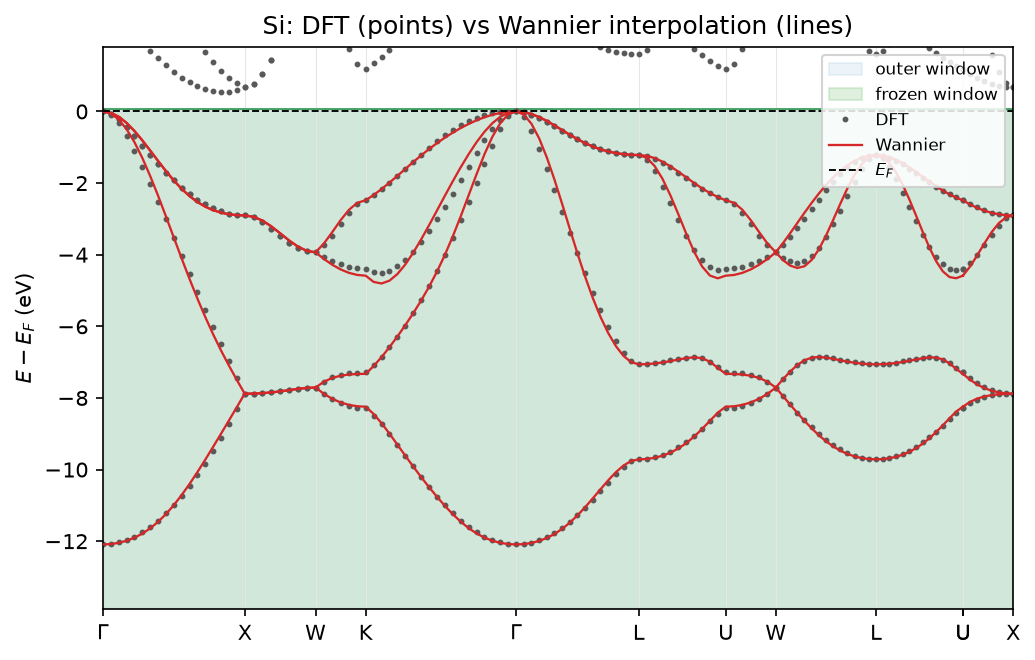

on the Wannier mesh, inside the frozen window: max 0.000 meV, rms 0.000 meV over 256 states


In [7]:
from waw.interfaces.ase.structure import band_path
from waw.core.hamiltonian import interpolate_bands
from waw.interfaces.quantum_espresso import bands_along_path
from waw.analysis.bands import mesh_fidelity
from waw.vis import plot_wannierization_windows

E_F = ov_mv['fermi_energy']
bp = band_path(atoms, npoints=120)
xcoords, xspecial, labels = bp.get_linear_kpoint_axis()
bands = interpolate_bands(res_mv.hr, bp.kpts) * HARTREE_TO_EV
try:
    dft_bands = bands_along_path(WORK, 'si_mv', bp.kpts, ncores=NCORES)
except FileNotFoundError as exc:      # charge density not kept in this run dir
    dft_bands = np.full_like(bands, np.nan)
    print(exc)

fig, ax = plt.subplots(figsize=(7, 4.5), dpi=150)
plot_wannierization_windows(
    ax, xcoords, dft_bands, bands,
    outer_window=(-1e6, 6.5), frozen_window=(-1e6, 6.5), fermi_energy=E_F,
    xticks=xspecial, xticklabels=[l.replace('G', r'$\Gamma$') for l in labels])
ax.set_title('Si: DFT (points) vs Wannier interpolation (lines)')
plt.tight_layout(); plt.show()

fid = mesh_fidelity(res_mv.hr, ov_mv['kpts'], ov_mv['eig'],
                    window=(-1e6, 6.5), fermi_ev=E_F)
print(f"on the Wannier mesh, inside the frozen window: max {fid['max']:.3f} meV, "
      f"rms {fid['rms']:.3f} meV over {fid['n_states']} states")


**Cross-validation status for `use_ss_functional` itself.** `strings $(which wannier90.x) | grep -i use_ss_functional` returns NOTHING for this environment's QE-7.5-bundled build (self-reports v3.1.0) — the same way `kdotp`/`dis_froz_proj` were already found absent in tutorials 33/34's own builds. This isn't merely the keyword defaulting to off: the string doesn't exist anywhere in the compiled binary, meaning this build's Fortran source predates the feature entirely. The Stengel-Spaldin variant (section 3) therefore could NOT be cross-checked against a real `wannier90.x`/`postw90.x` run in this environment. What COULD be, and was: the plain MV pathway (section 2) — the SAME `disentangle`/overlap/projection plumbing both variants share — matches real `wannier90.x` to 9 decimal places, and `core.spread.compute_ss_spread` itself has 8 passing unit tests (`tests/test_ss_spread.py`, including an autodiff-vs-finite-difference gradient check and a synthetic-model check that Omega_I/Omega_OD reduce to the ordinary MV values exactly) plus a full end-to-end `wannierize(use_ss_functional=True)` smoke test.

**Takeaway.** `use_ss_functional` (Stengel & Spaldin's alternative localization functional) is now wired end-to-end in waw exactly like any other `wannierize()` optimizer kwarg. On real silicon DFT data: the shared MV pipeline underneath both variants matches real `wannier90.x` to 9 decimal places; the SS functional itself gives a *larger* $\Omega_D$ than MV on the 8-orbital valence+conduction system studied here, refuting any general $\Omega^{\rm SS}\le\Omega^{\rm MV}$ ordering; and a genuine `omega_final`/`use_ss_functional` reporting bug in `core/pipeline.py` was found and fixed along the way.